## Importing libraries and formatting plots

In [1]:
# Importing crap
# %load_ext autoreload
# %autoreload 2

import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import numexpr

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import os

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.title_fontsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['mathtext.fontset'] = 'cm'

## Reading in analysis output file

In [2]:
multipliers = [1e-1, 3e-1, 1e0, 3e0, 1e1]

df_list = []
thresholds_list = []
radius_list = []

one_e_4_list = []
three_e_4_list = []
one_e_3_list = []
three_e_3_list = []
one_e_2_list = []

for multiplier in multipliers:
    df = pd.read_csv(f'./Data Files/analysis_output_{multiplier:.0e}.csv')
    df_list.append(df)

    thresholds = np.array(df.columns[4:], dtype=float)
    thresholds_list.append(thresholds)

    radius = np.array(df['source_radius'].to_list())
    radius_list.append(radius)

    one_e_4 = np.array(df['1.1e-04'].to_list())
    one_e_4_list.append(one_e_4)

    three_e_4 = np.array(df['3.4e-04'].to_list())
    three_e_4_list.append(three_e_4)

    one_e_3 = np.array(df['1.0e-03'].to_list())
    one_e_3_list.append(one_e_3)

    three_e_3 = np.array(df['3.1e-03'].to_list())
    three_e_3_list.append(three_e_3)

    one_e_2 = np.array(df['1.1e-02'].to_list())
    one_e_2_list.append(one_e_2)

In [3]:
ss_str_1 = np.array(df_list[0]['s'].to_list(), dtype=str)
ss_1 = np.array([numexpr.evaluate(str(s)) for s in df_list[0]['s'].to_list()])
qs_1 = np.array(df_list[0]['q'].to_list())

ss_str_unique_1 = np.array(['0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0', '1/0.9', '1/0.8', '1/0.7', '1/0.6', '1/0.5', '1/0.4', '1/0.3', '1/0.2'], dtype=str)
ss_unique_1 = np.array([numexpr.evaluate(s) for s in ss_str_unique_1], dtype=float)
qs_unique_1 = np.unique(qs_1)

print(ss_str_unique_1)
print(qs_unique_1)

['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.9' '1/0.8'
 '1/0.7' '1/0.6' '1/0.5' '1/0.4' '1/0.3' '1/0.2']
[1.e-06 3.e-06 1.e-05 3.e-05 1.e-04 3.e-04 1.e-03]


## Plotting fractional area above threshold as a function of threshold

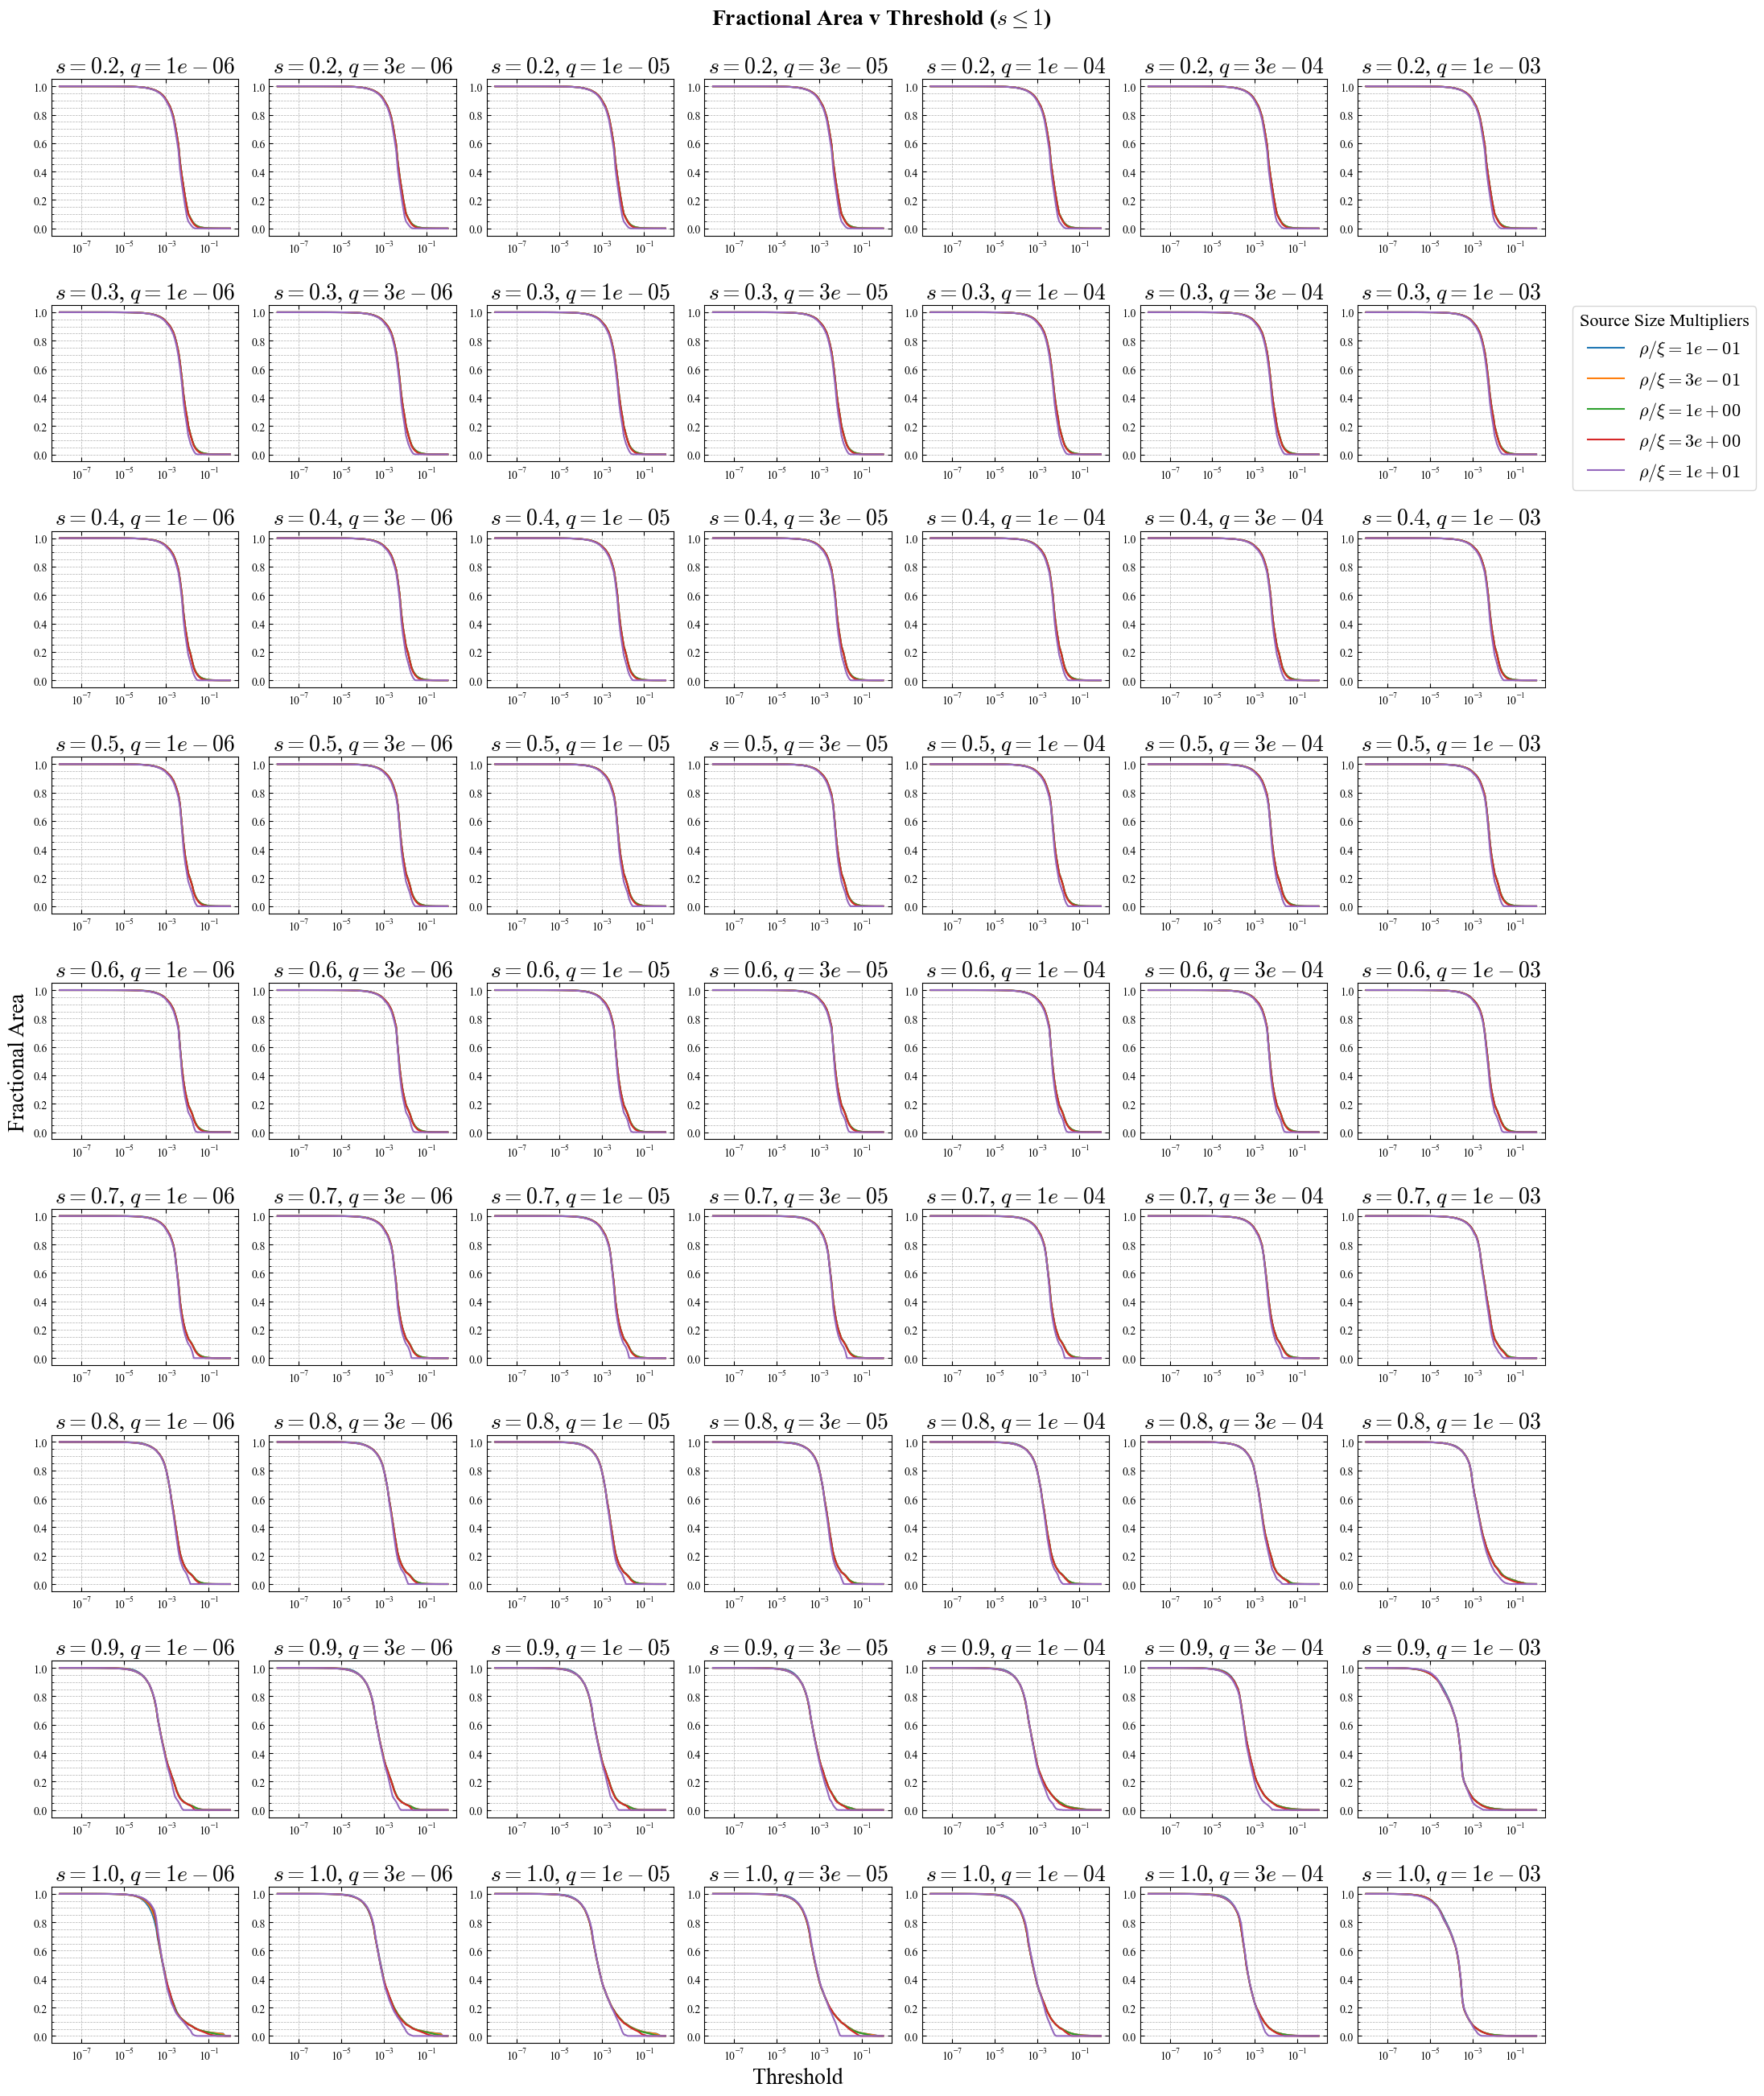

In [4]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(9, 7)

# combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Threshold ($s \leq 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 <= 1.0]):
    for j, q in enumerate(qs_unique_1):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $q={q:.0e}$')

        df_subset1 = df_list[0][(df_list[0]['s'] == s) & (df_list[0]['q'] == q)]
        df_subset2 = df_list[1][(df_list[1]['s'] == s) & (df_list[1]['q'] == q)]
        df_subset3 = df_list[2][(df_list[2]['s'] == s) & (df_list[2]['q'] == q)]
        df_subset4 = df_list[3][(df_list[3]['s'] == s) & (df_list[3]['q'] == q)]
        df_subset5 = df_list[4][(df_list[4]['s'] == s) & (df_list[4]['q'] == q)]
        # df_subset = df_subset.sort_values(by='source_radius')

        ax.plot(thresholds, df_subset1.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[0]:.0e}$')
        ax.plot(thresholds, df_subset2.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[1]:.0e}$')
        ax.plot(thresholds, df_subset3.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[2]:.0e}$')
        ax.plot(thresholds, df_subset4.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[3]:.0e}$')
        ax.plot(thresholds, df_subset5.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[4]:.0e}$')

        ax.set_xscale('log')
        # ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 3].set_xlabel('Threshold')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Source Size Multipliers')

# fig.savefig('./Figures/fractional_area_v_threshold_s_less_than_1.png', dpi=300)

plt.show()

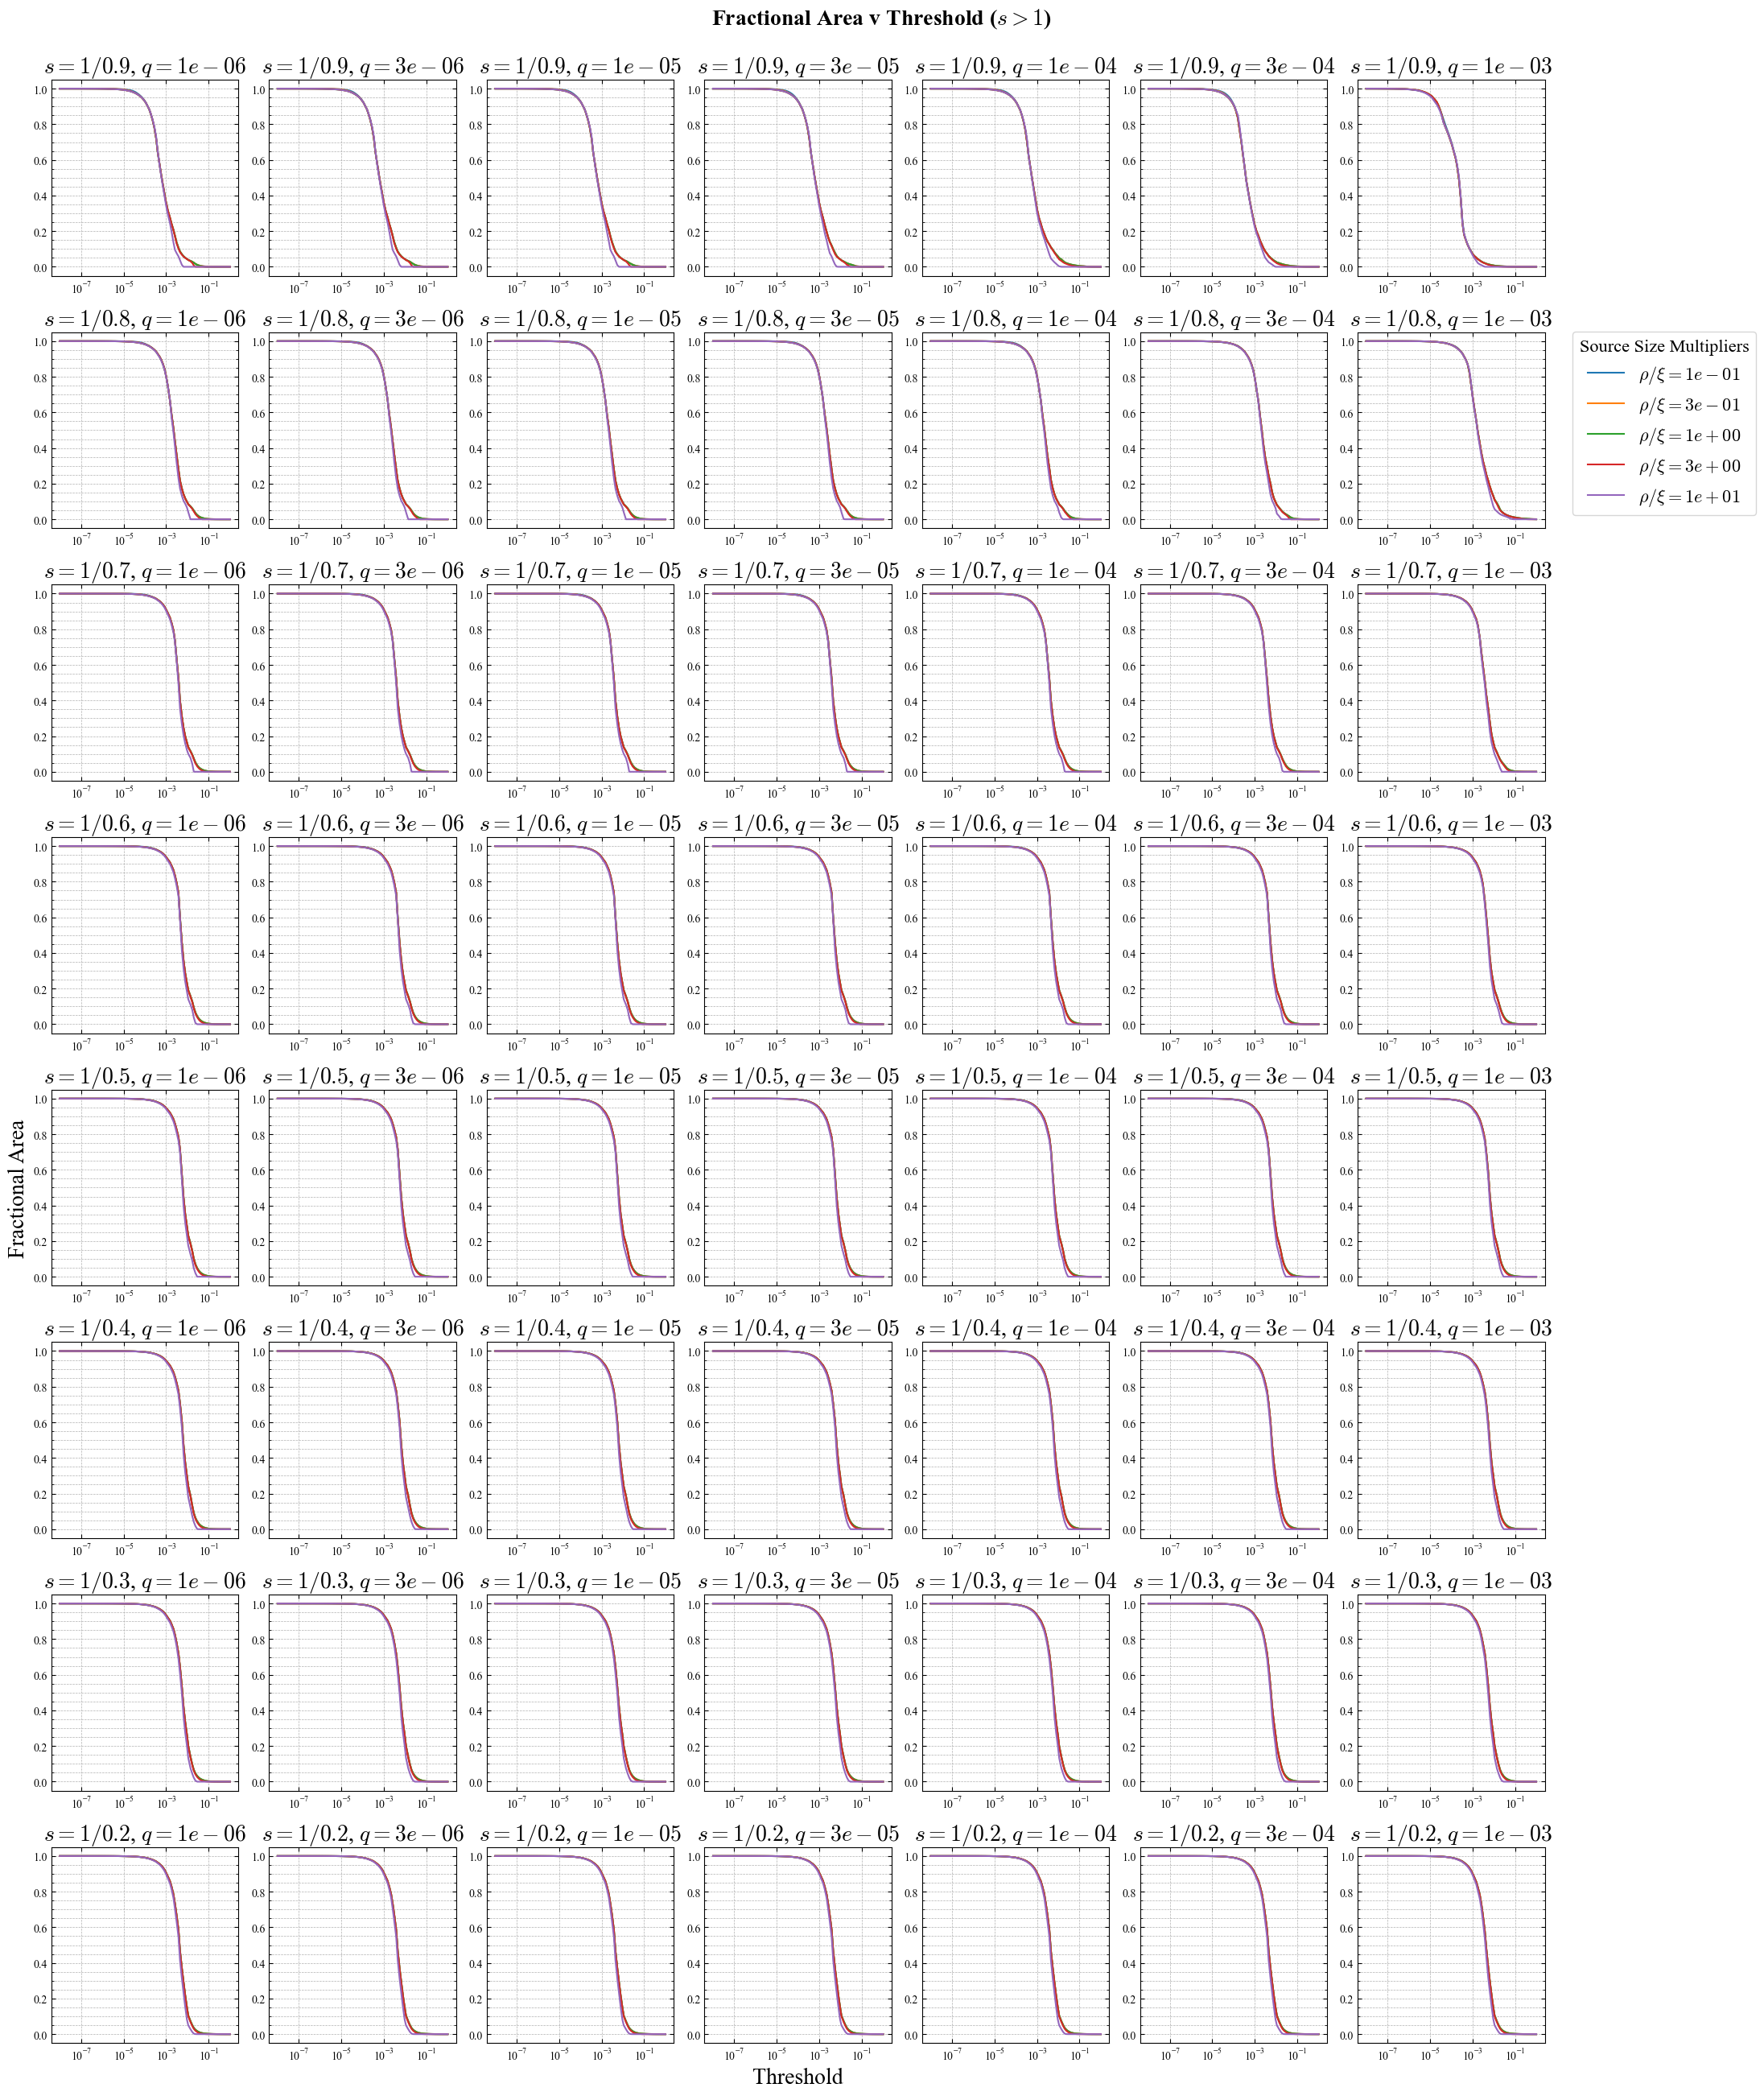

In [5]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(8, 7)

# combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Threshold ($s > 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 > 1.0]):
    for j, q in enumerate(qs_unique_1):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $q={q:.0e}$')

        df_subset1 = df_list[0][(df_list[0]['s'] == s) & (df_list[0]['q'] == q)]
        df_subset2 = df_list[1][(df_list[1]['s'] == s) & (df_list[1]['q'] == q)]
        df_subset3 = df_list[2][(df_list[2]['s'] == s) & (df_list[2]['q'] == q)]
        df_subset4 = df_list[3][(df_list[3]['s'] == s) & (df_list[3]['q'] == q)]
        df_subset5 = df_list[4][(df_list[4]['s'] == s) & (df_list[4]['q'] == q)]
        # df_subset = df_subset.sort_values(by='source_radius')

        ax.plot(thresholds, df_subset1.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[0]:.0e}$')
        ax.plot(thresholds, df_subset2.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[1]:.0e}$')
        ax.plot(thresholds, df_subset3.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[2]:.0e}$')
        ax.plot(thresholds, df_subset4.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[3]:.0e}$')
        ax.plot(thresholds, df_subset5.iloc[0, 4:], label=f'$\\rho/\\xi = {multipliers[4]:.0e}$')

        ax.set_xscale('log')
        # ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 3].set_xlabel('Threshold')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Source Size Multipliers')

# fig.savefig('./Figures/fractional_area_v_threshold_s_greater_than_1.png', dpi=300)

plt.show()

## First, plotting fractional area as a function of source star radius for different thresholds

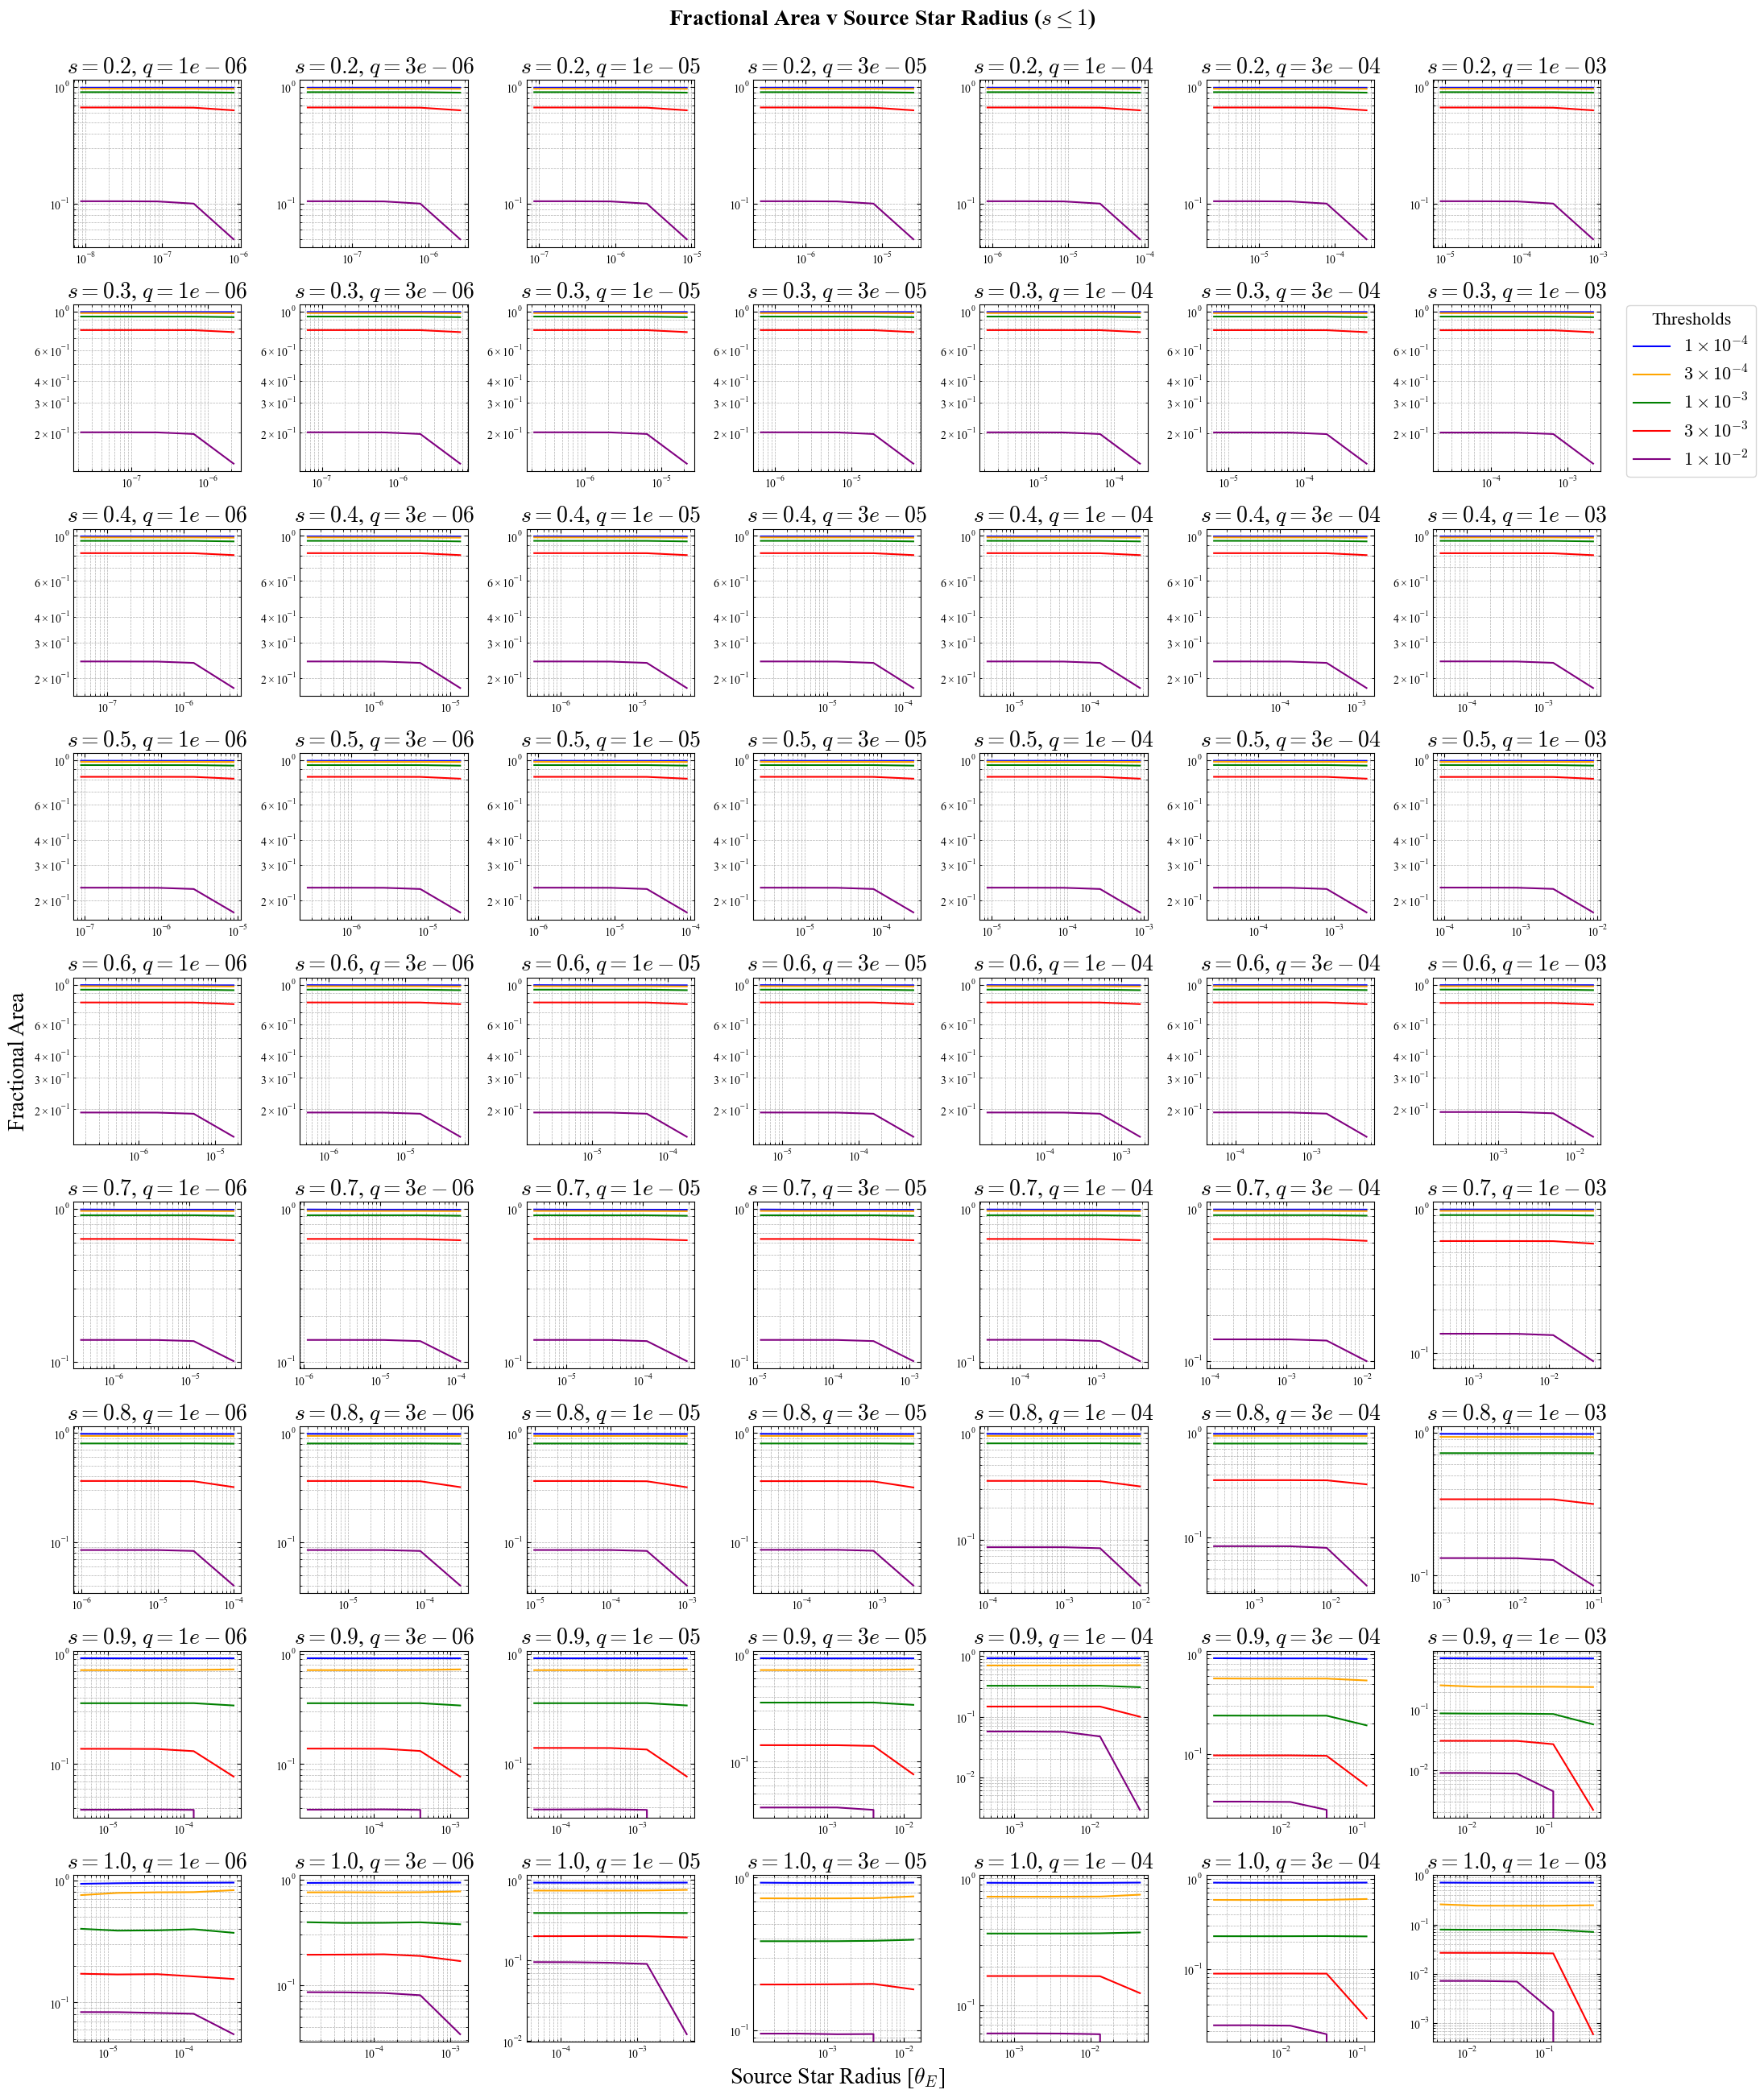

In [6]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(9, 7)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Source Star Radius ($s \leq 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 <= 1.0]):
    for j, q in enumerate(qs_unique_1):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $q={q:.0e}$')

        df_subset = combined_df[(combined_df['s'] == s) & (combined_df['q'] == q)]
        df_subset = df_subset.sort_values(by='source_radius')

        ax.plot(df_subset['source_radius'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['source_radius'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['source_radius'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['source_radius'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['source_radius'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 3].set_xlabel('Source Star Radius [$\\theta_E$]')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

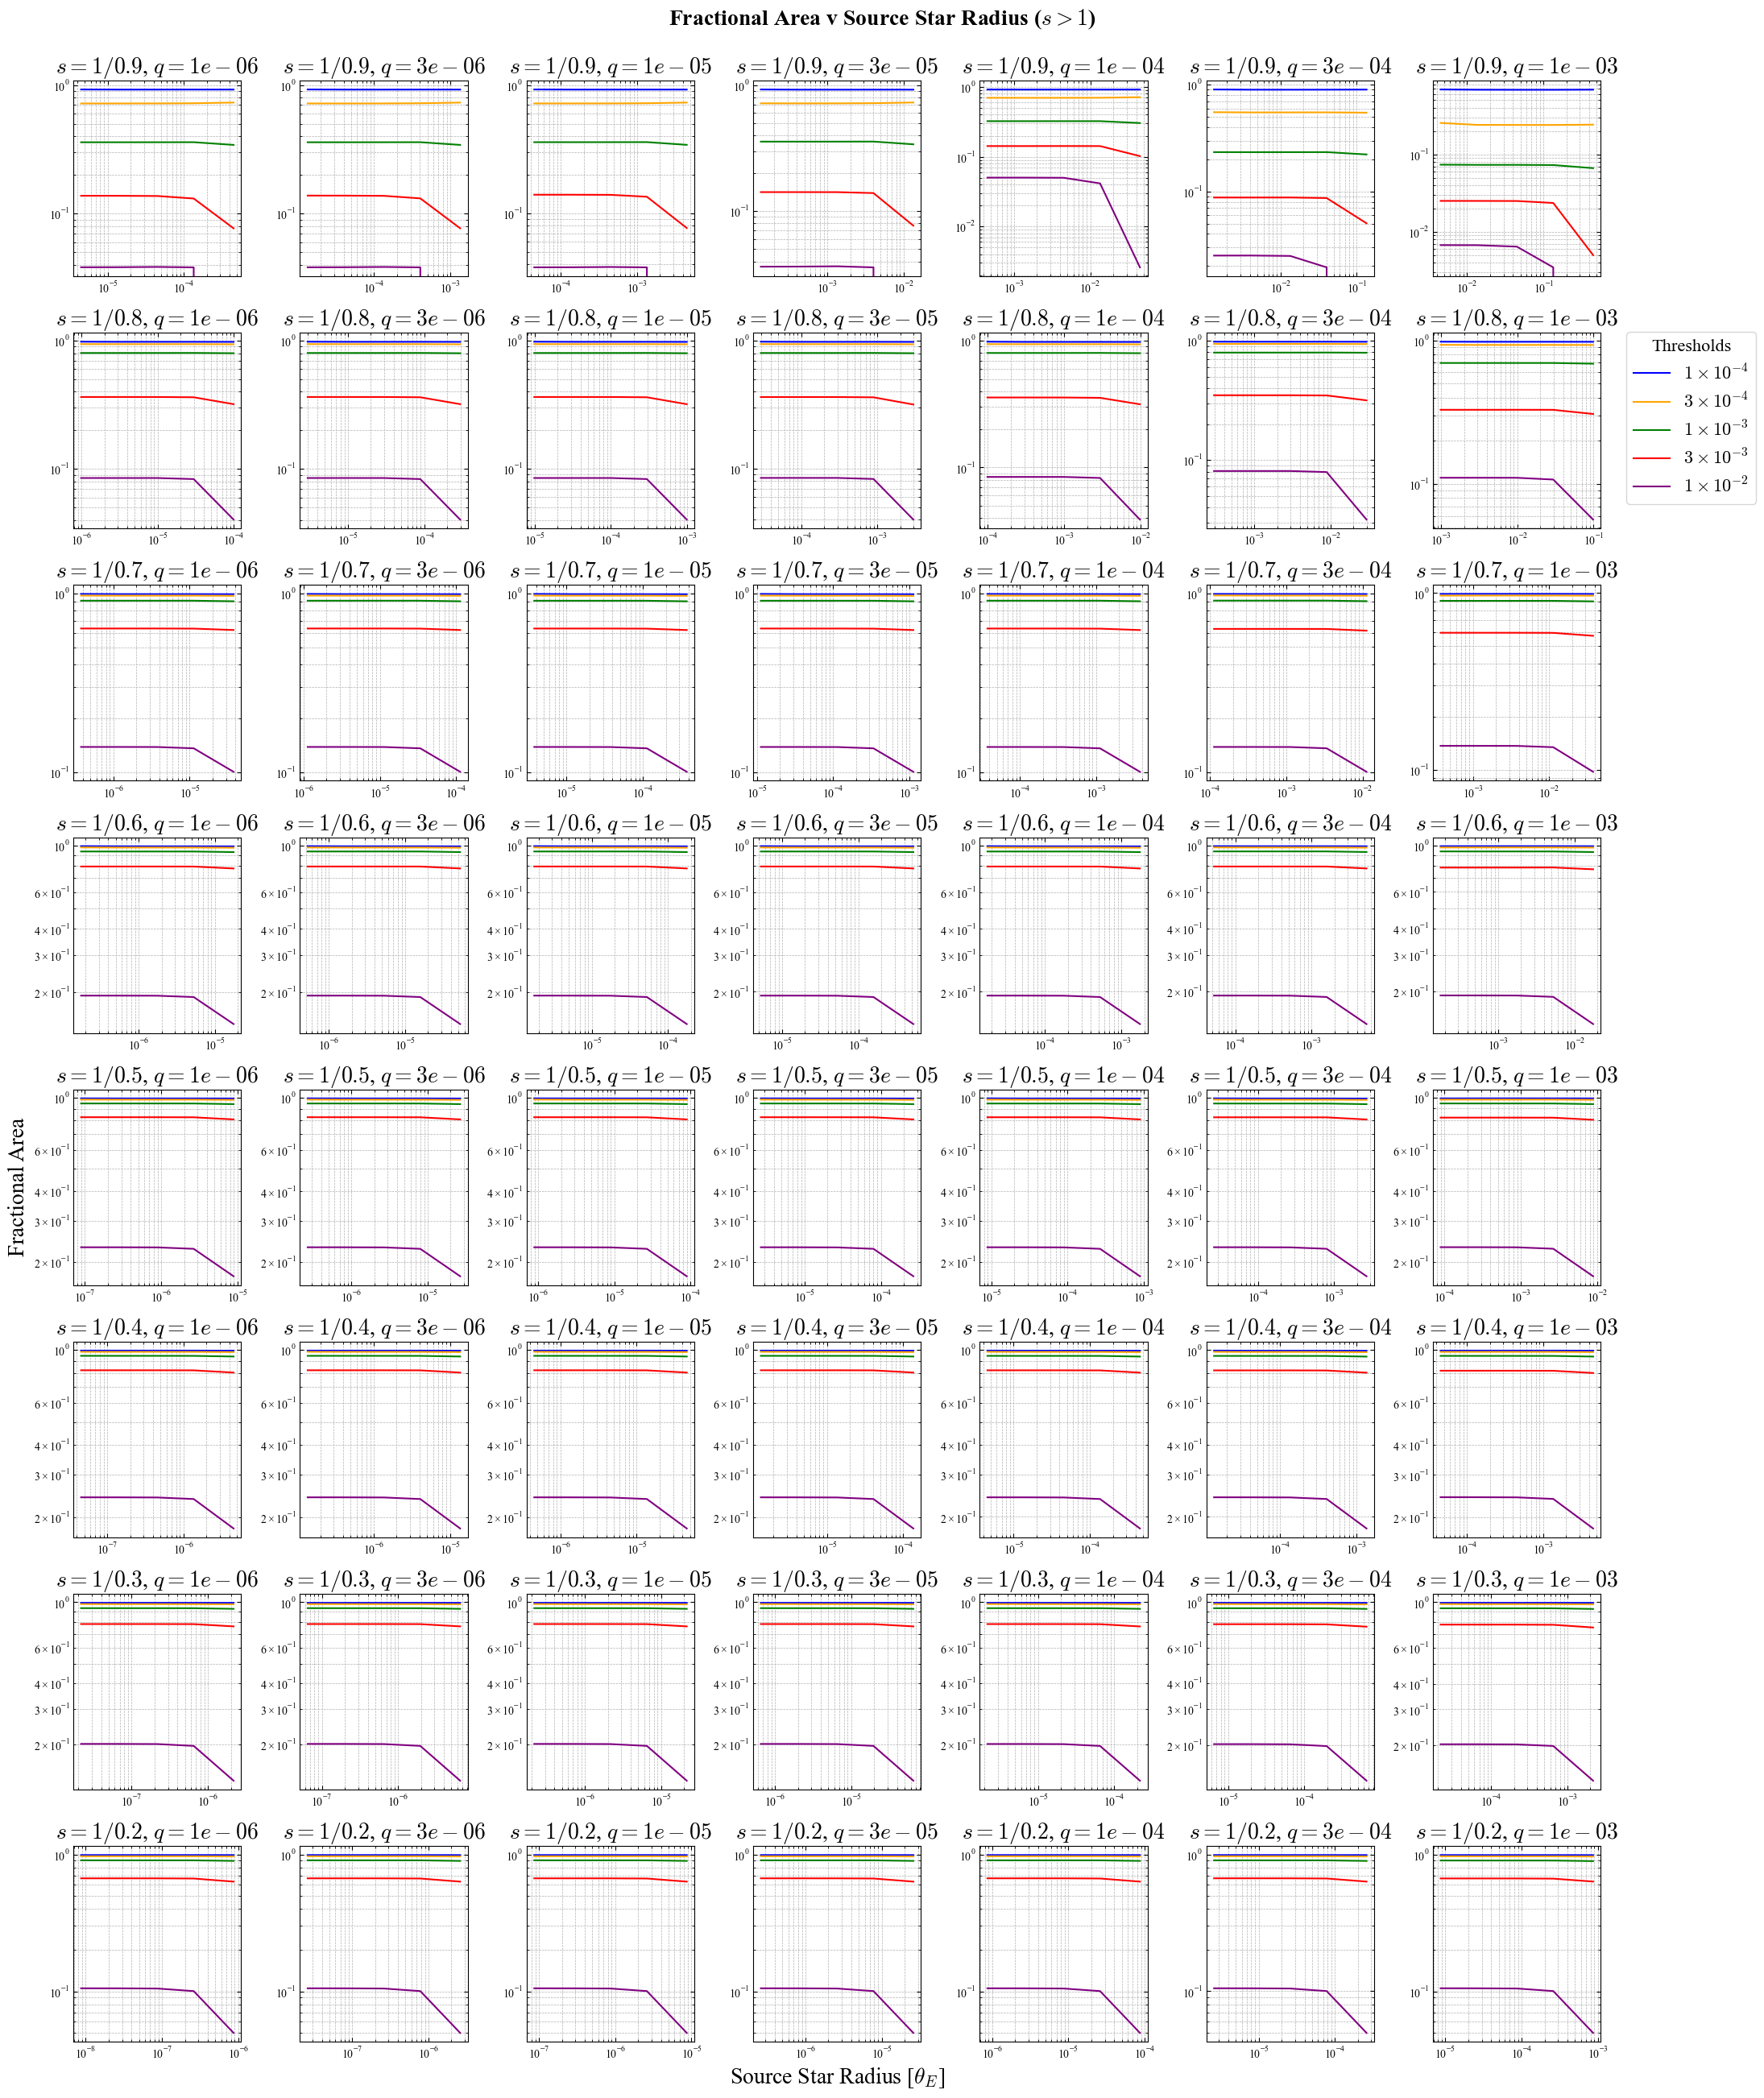

In [7]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(8, 7)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Source Star Radius ($s > 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 > 1.0]):
    for j, q in enumerate(qs_unique_1):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $q={q:.0e}$')

        df_subset = combined_df[(combined_df['s'] == s) & (combined_df['q'] == q)]
        df_subset = df_subset.sort_values(by='source_radius')

        if df_subset.empty:
            continue

        ax.plot(df_subset['source_radius'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['source_radius'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['source_radius'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['source_radius'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['source_radius'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 3].set_xlabel('Source Star Radius [$\\theta_E$]')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

# Second, plotting fractional area as a function of separation for different thresholds

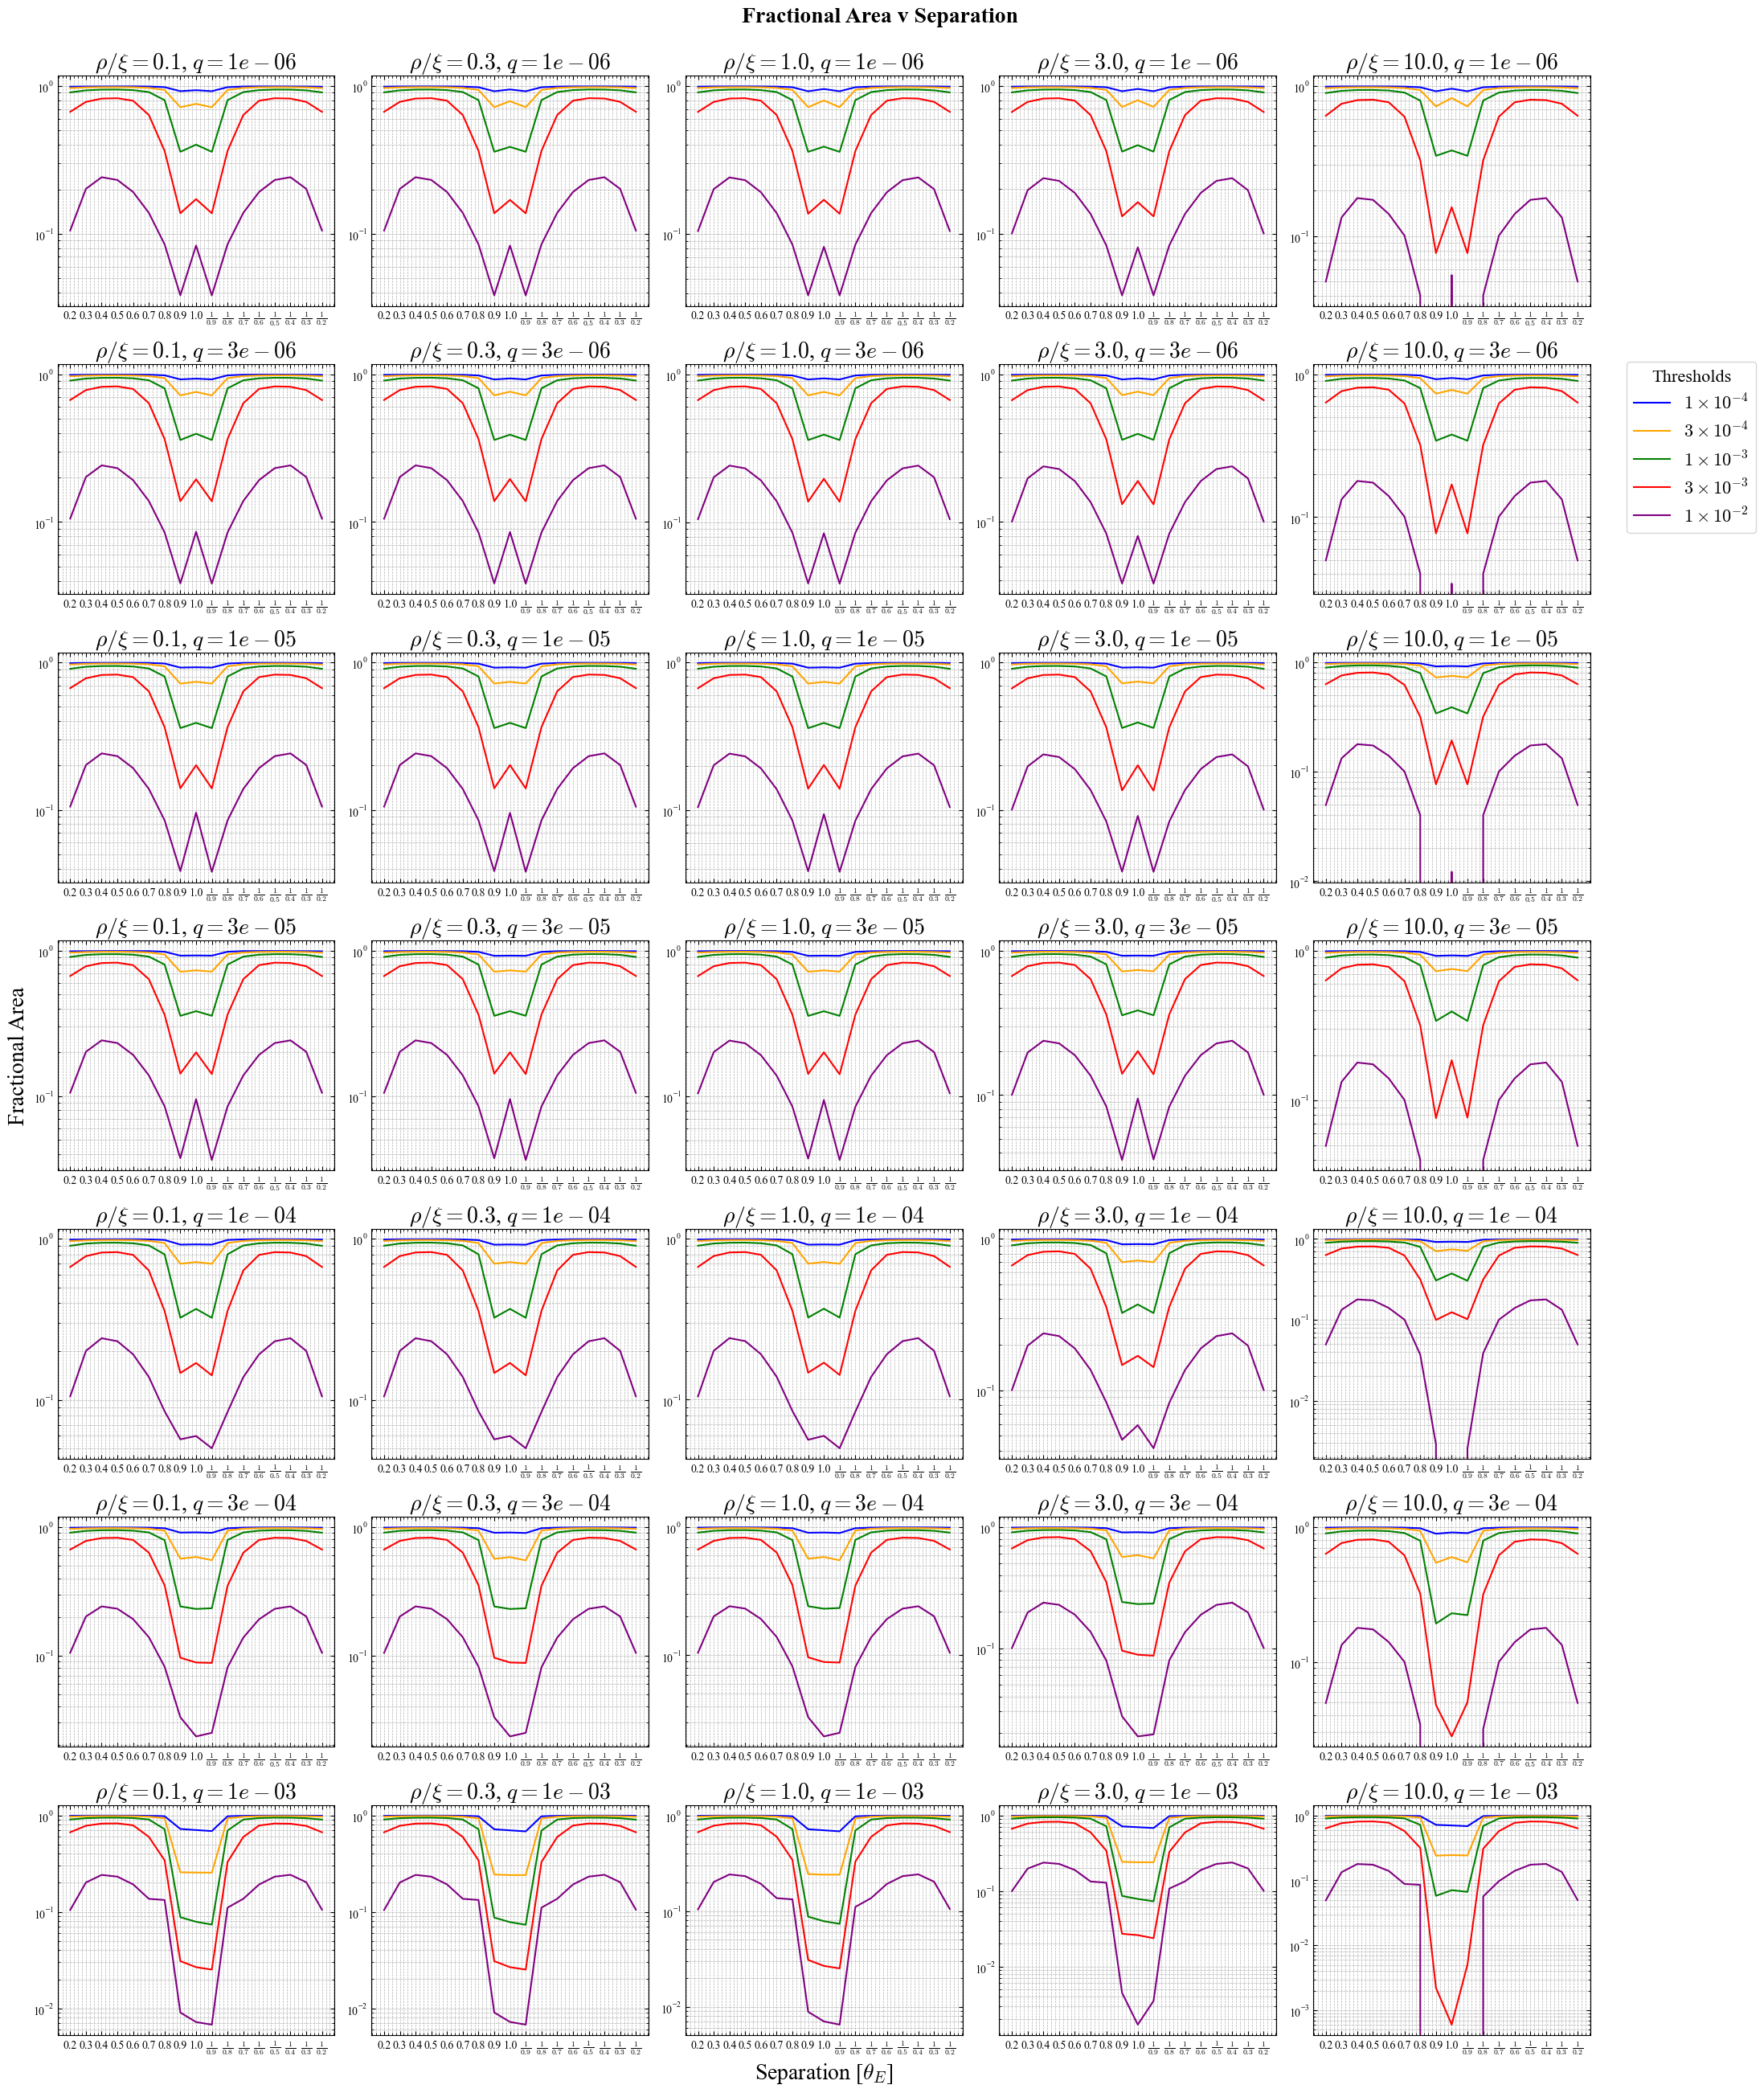

In [8]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(7, 5)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Separation', y=1.0)

for i, q in enumerate(qs_unique_1):
    for j, multiplier in enumerate(multipliers):
        ax = axes[i, j]

        ax.set_title(f'$\\rho/\\xi={multiplier}$, $q={q:.0e}$')

        df_subset = df_list[j][(df_list[j]['q'] == q)]
        # df_subset = df_subset.sort_values(by='s')

        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(np.linspace(0, 1, len(df_subset)), df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')
        # ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_xticks(np.linspace(0, 1, len(df_subset)))

        # Using stacked fractions for the x-ticks to show separation values instead of indices
        ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_1])

axes[-1, 2].set_xlabel('Separation [$\\theta_E$]')
axes[3, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

# fig.savefig('./Figures/fractional_area_v_separation.png', dpi=300)

plt.show()

## Third, plotting fractional area as a function of q for different thesholds

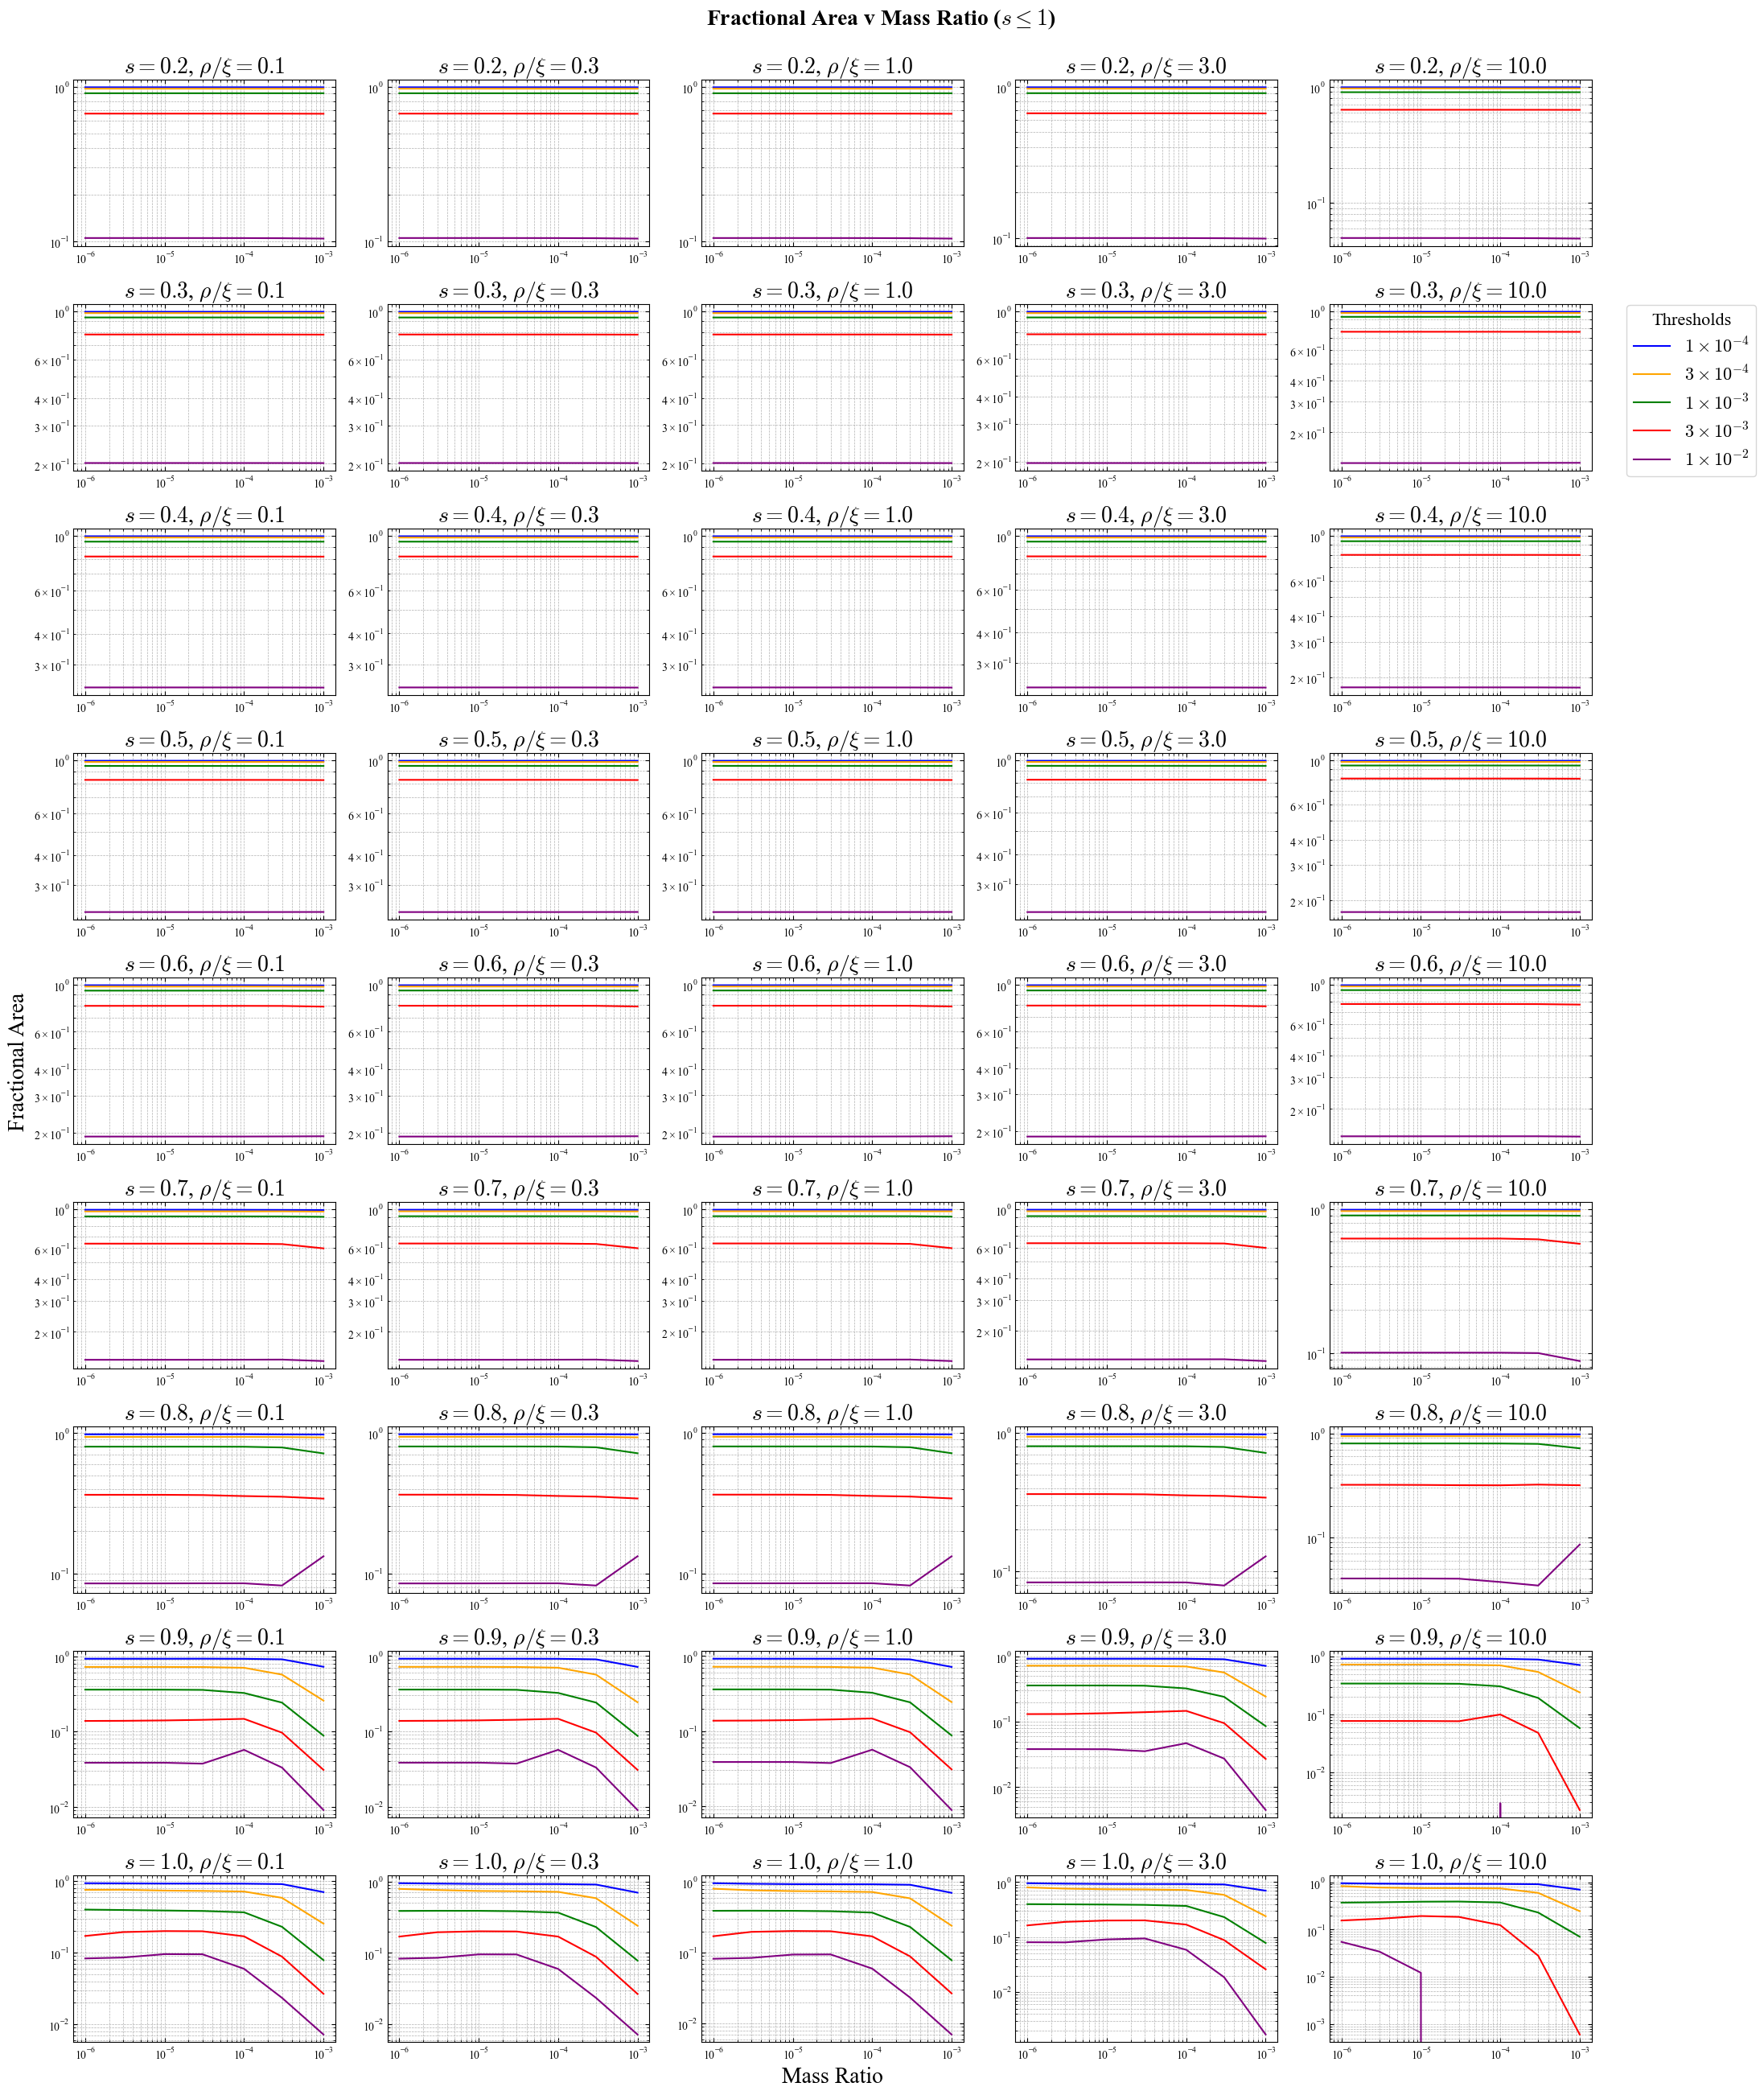

In [9]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(9, 5)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Mass Ratio ($s \leq 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 <= 1.0]):
    for j, multiplier in enumerate(multipliers):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $\\rho/\\xi={multiplier}$')

        df_subset = df_list[j][(df_list[j]['s'] == s)]
        df_subset = df_subset.sort_values(by='q')

        ax.plot(df_subset['q'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['q'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['q'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['q'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['q'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Mass Ratio')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

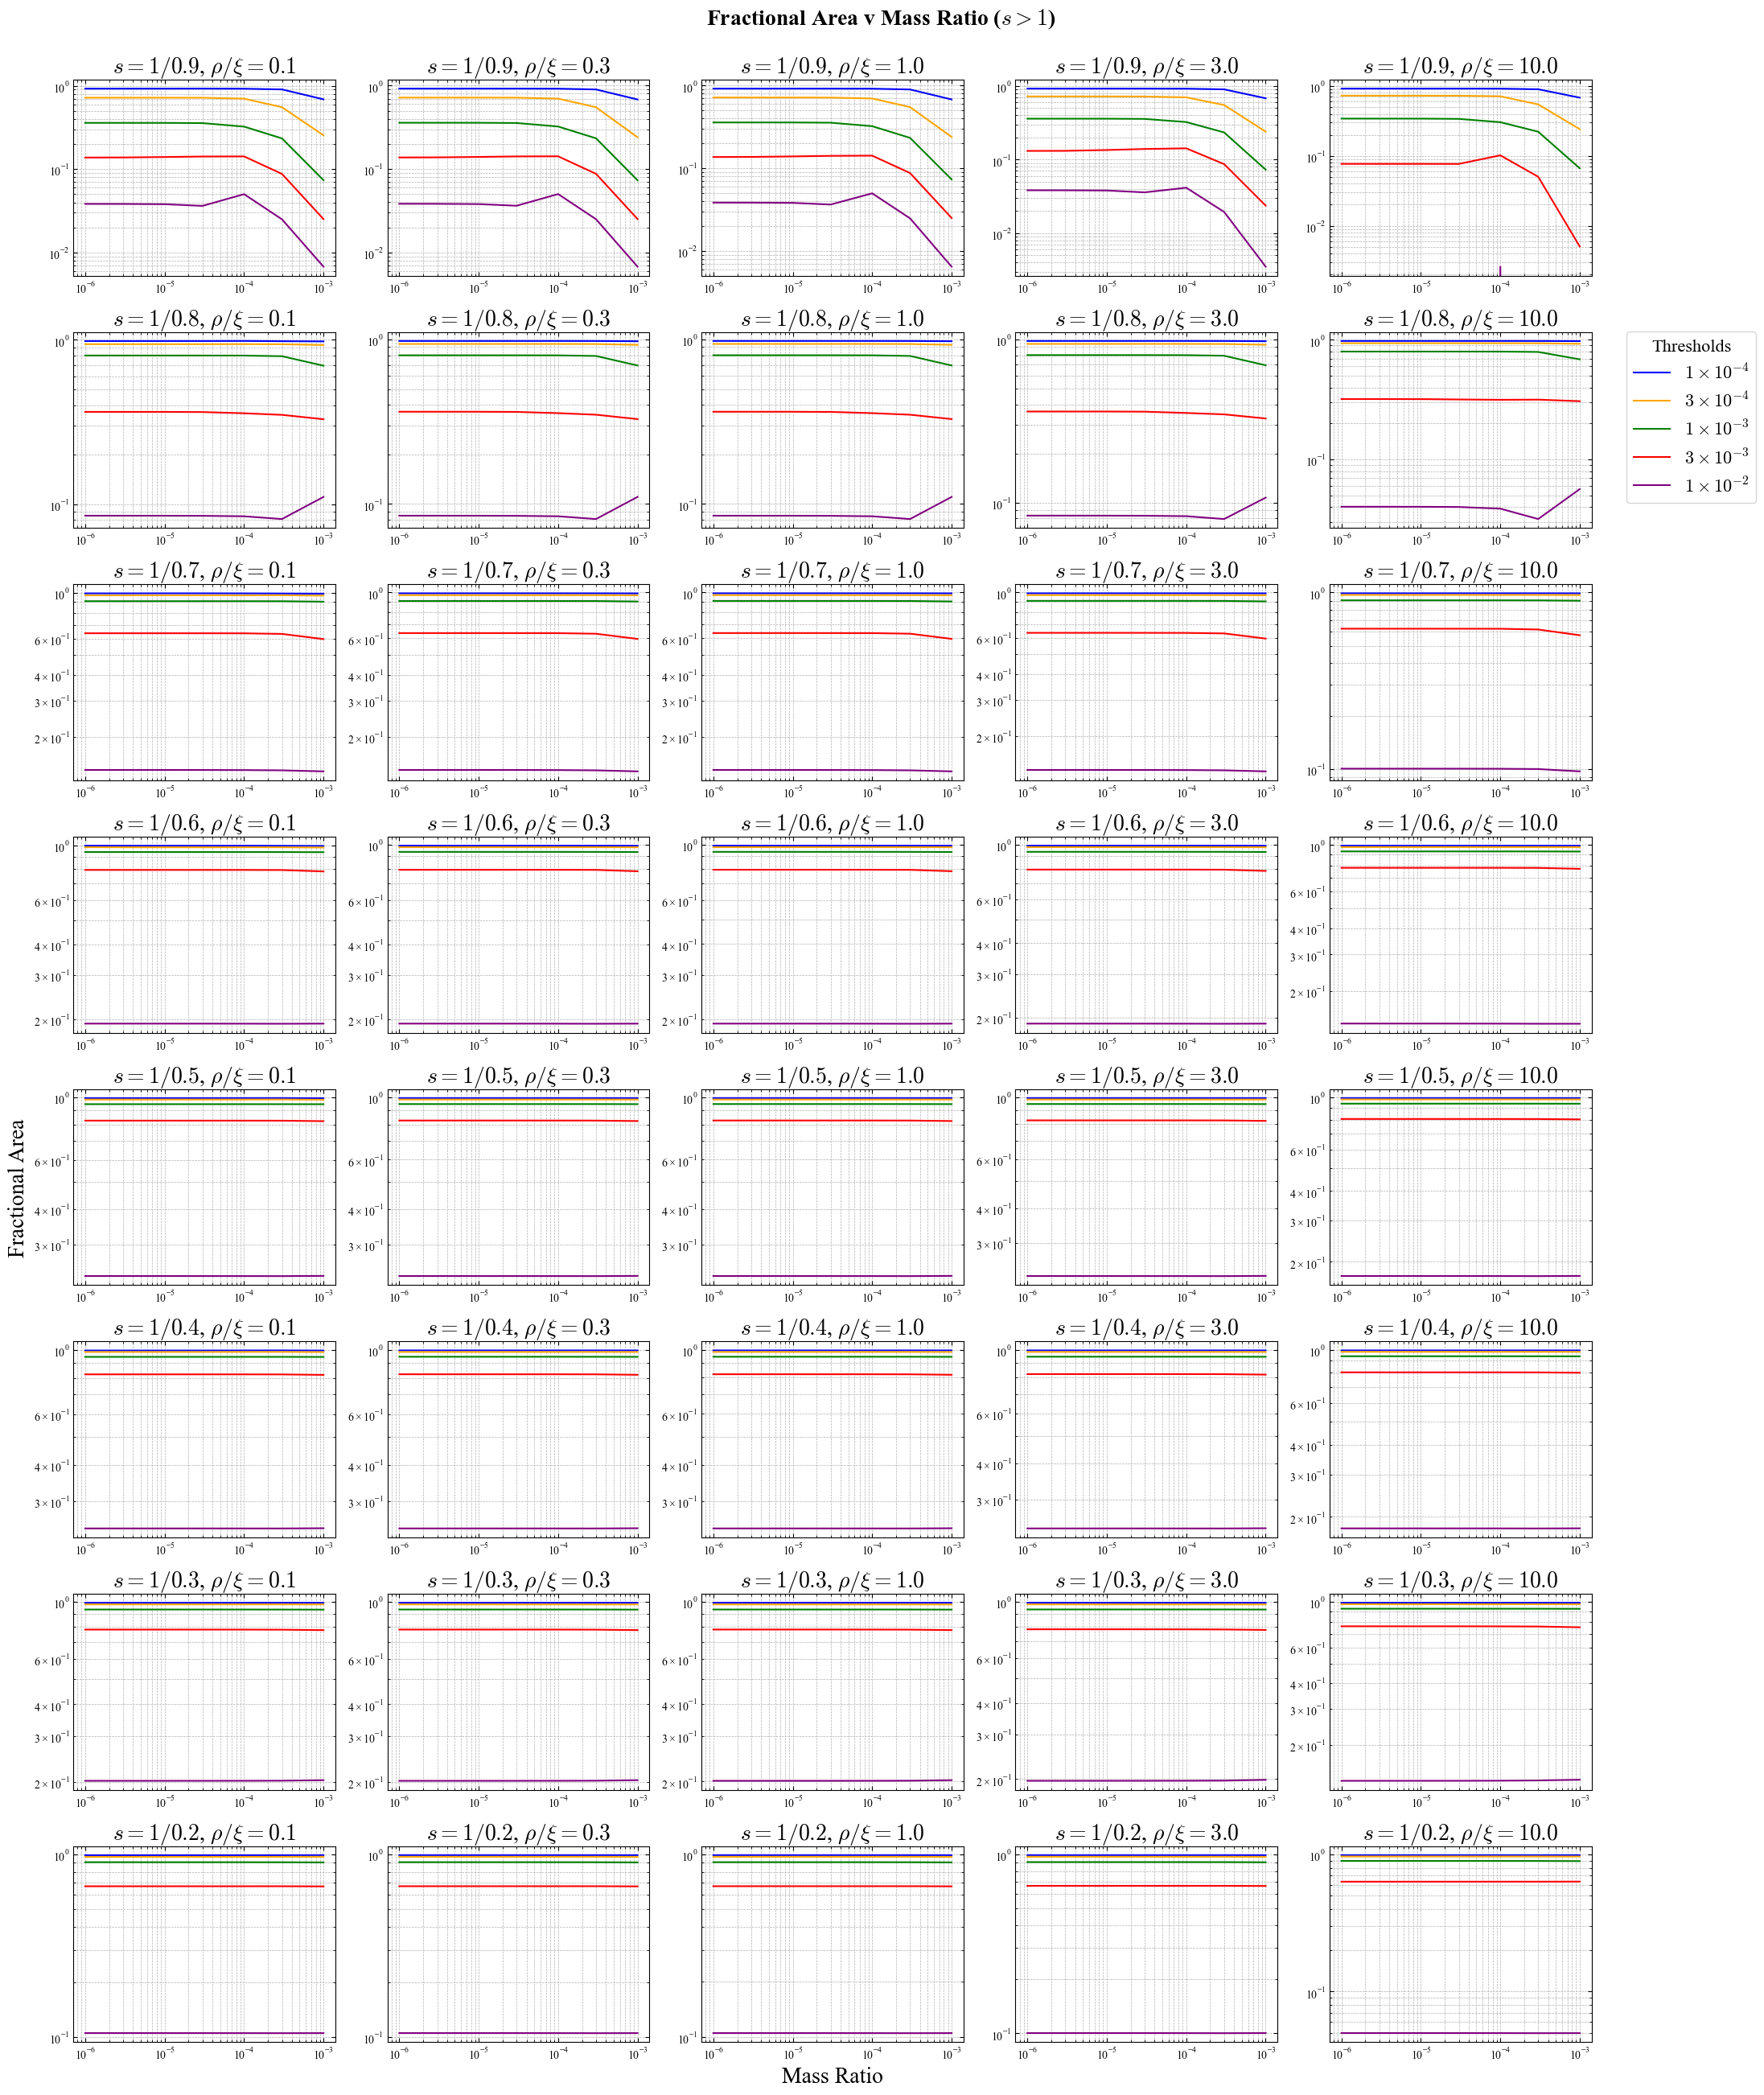

In [10]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(8, 5)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Mass Ratio ($s > 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 > 1.0]):
    for j, multiplier in enumerate(multipliers):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $\\rho/\\xi={multiplier}$')

        df_subset = df_list[j][(df_list[j]['s'] == s)]
        df_subset = df_subset.sort_values(by='q')

        ax.plot(df_subset['q'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['q'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['q'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['q'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['q'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Mass Ratio')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

## Fourth, plotting q and s with fractional area as color scale for different thresholds

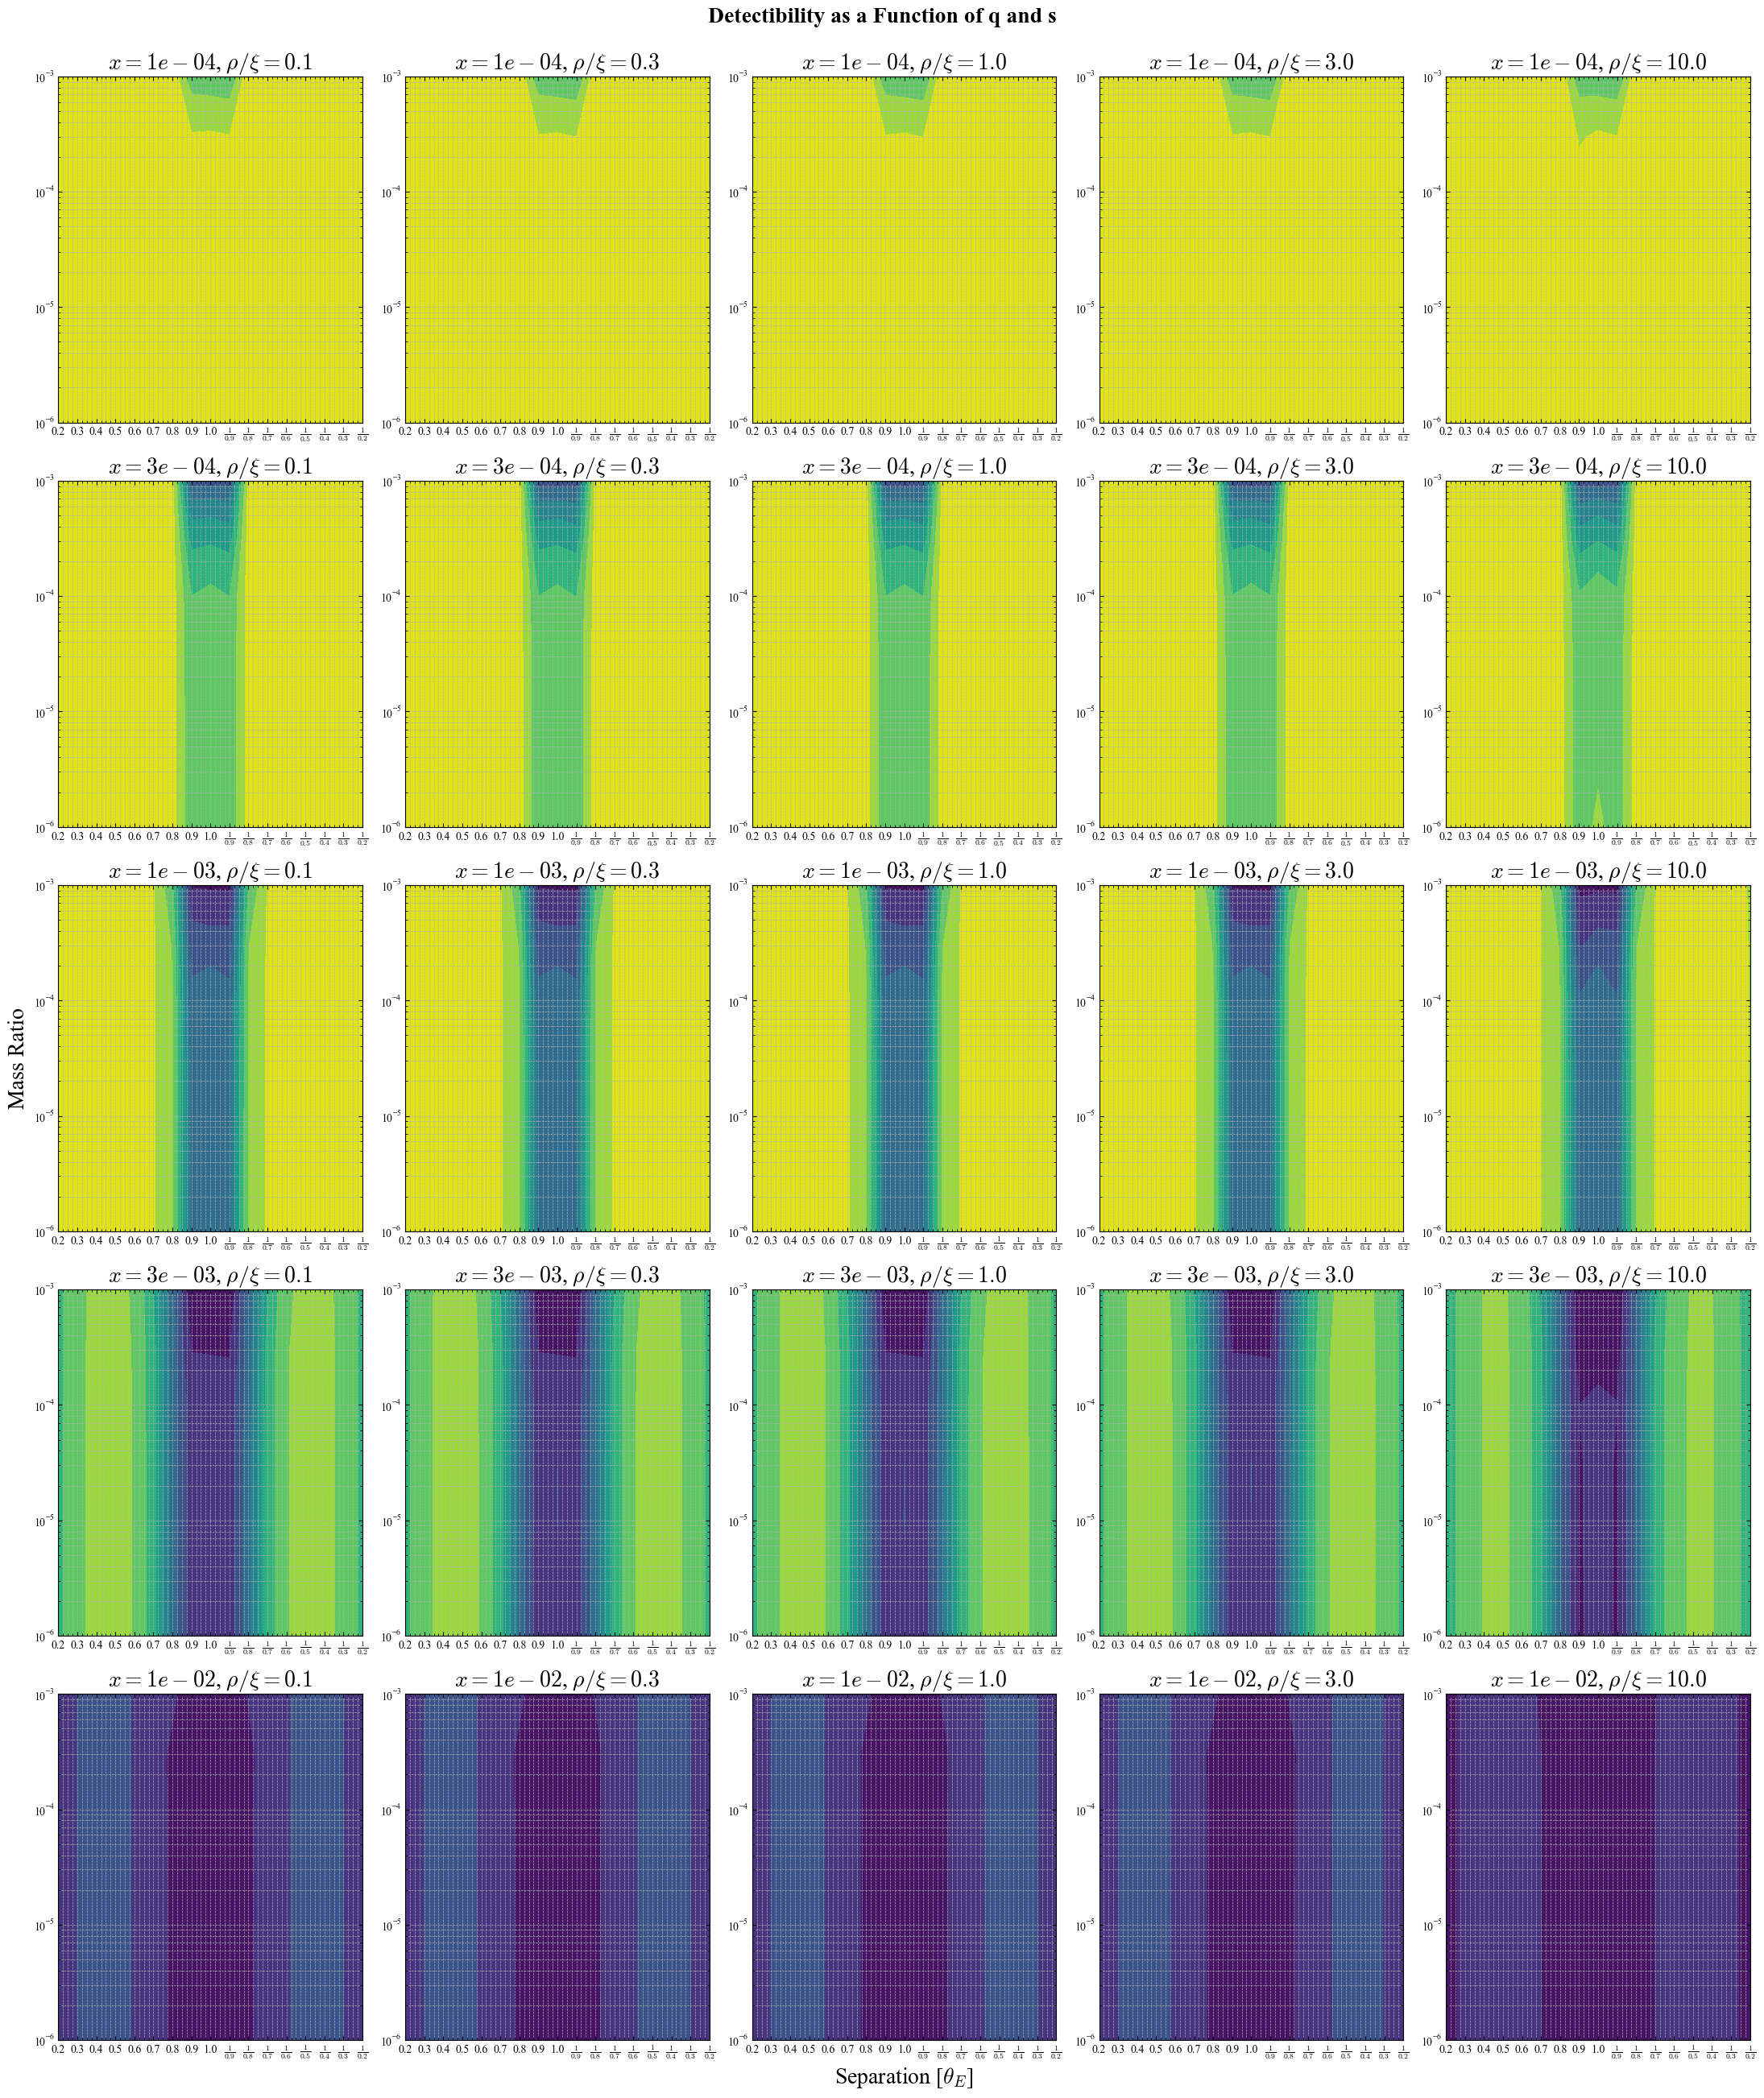

In [31]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(5, 5)

fig.suptitle('Detectibility as a Function of q and s', y=1.0)

for i, threshold in enumerate([1.1e-04, 3.4e-04, 1.0e-03, 3.1e-03, 1.1e-02]):
    for j, multiplier in enumerate(multipliers):
        ax = axes[i, j]

        ax.set_title(f'$x={threshold:.0e}$, $\\rho/\\xi={multiplier}$')

        df_subset = df_list[j]
        # df_subset = df_subset.sort_values(by='q').reset_index(drop=True)

        # Fixing holes in data
        # empty_arr = ['1/0.2', 3e-4] + [np.nan] * 102
        # df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[116.5])], ignore_index=False)

        # empty_arr = ['1/0.2', 1e-3] + [np.nan] * 102
        # df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[117.5])], ignore_index=False)
        # df_subset = df_subset.sort_index().reset_index(drop=True)

        # empty_arr = ['1/0.4', 1e-3] + [np.nan] * 102
        # df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[103.5])], ignore_index=False)

        # df_subset = df_subset.sort_index().reset_index(drop=True)

        # ax.imshow(np.array(df_subset[f'{threshold:.1e}']).reshape((17, 7)).T, extent=[
        #     ss_unique_1.min(), ss_unique_1.max(),
        #     qs_unique_1.min(), qs_unique_1.max()
        # ], aspect='auto', origin='lower', norm=plt.Normalize(vmin=0, vmax=1), cmap='viridis')

        ax.contourf(
            np.linspace(0, 1, 17),
            qs_unique_1,
            np.array(df_subset[f'{threshold:.1e}']).reshape((7, 17)),
            levels=np.linspace(0, 1, 11),
            cmap='viridis',
            vmin=0, vmax=1
        )

        # ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_xticks(np.linspace(0, 1, 17))
        # ax.set_xticklabels(ss_str_unique_1)
        ax.set_xticklabels([f'$\\frac{{{s.split("/")[0]}}}{{{s.split("/")[1]}}}$' if numexpr.evaluate(s) > 1.0 else f'{s}' for s in ss_str_unique_1])

axes[-1, 2].set_xlabel('Separation [$\\theta_E$]')
axes[2, 0].set_ylabel('Mass Ratio')

# axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

In [30]:
arr = np.array(df_subset['s'].to_list())
arr = arr.reshape((7, 17))
print(arr)

[['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.9' '1/0.8'
  '1/0.7' '1/0.6' '1/0.5' '1/0.4' '1/0.3' '1/0.2']
 ['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.9' '1/0.8'
  '1/0.7' '1/0.6' '1/0.5' '1/0.4' '1/0.3' '1/0.2']
 ['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.9' '1/0.8'
  '1/0.7' '1/0.6' '1/0.5' '1/0.4' '1/0.3' '1/0.2']
 ['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.9' '1/0.8'
  '1/0.7' '1/0.6' '1/0.5' '1/0.4' '1/0.3' '1/0.2']
 ['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.9' '1/0.8'
  '1/0.7' '1/0.6' '1/0.5' '1/0.4' '1/0.3' '1/0.2']
 ['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.9' '1/0.8'
  '1/0.7' '1/0.6' '1/0.5' '1/0.4' '1/0.3' '1/0.2']
 ['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.9' '1/0.8'
  '1/0.7' '1/0.6' '1/0.5' '1/0.4' '1/0.3' '1/0.2']]


In [13]:
df_subset.sort_values(by='q').reset_index(drop=True)

,s,q,source_radius,LD_coeff,1.0e-08,1.2e-08,1.5e-08,1.7e-08,2.1e-08,2.5e-08,...,1.9e-01,2.3e-01,2.7e-01,3.3e-01,3.9e-01,4.8e-01,5.7e-01,6.9e-01,8.3e-01,1.0e+00
0,0.2,0.000001,8.680556e-07,0.5,0.999999,0.999999,0.999999,0.999998,0.999998,0.999997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1/0.2,0.000001,8.680556e-07,0.5,0.999999,0.999999,0.999999,0.999999,0.999998,0.999998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1/0.3,0.000001,2.173651e-06,0.5,0.999999,0.999999,0.999999,0.999999,0.999999,0.999999,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1/0.4,0.000001,4.535147e-06,0.5,1.000000,0.999999,0.999999,0.999999,0.999999,0.999999,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1/0.5,0.000001,8.888889e-06,0.5,1.000000,0.999999,0.999999,0.999999,0.999999,0.999999,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,0.3,0.001000,2.173651e-03,0.5,0.999999,0.999999,0.999999,0.999999,0.999999,0.999998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
115,0.2,0.001000,8.680556e-04,0.5,0.999999,0.999999,0.999998,0.999998,0.999997,0.999997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
116,1/0.3,0.001000,2.173651e-03,0.5,1.000000,0.999999,0.999999,0.999999,0.999999,0.999998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117,0.9,0.001000,4.487535e-01,0.5,0.999967,0.999960,0.999951,0.999941,0.999928,0.999915,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


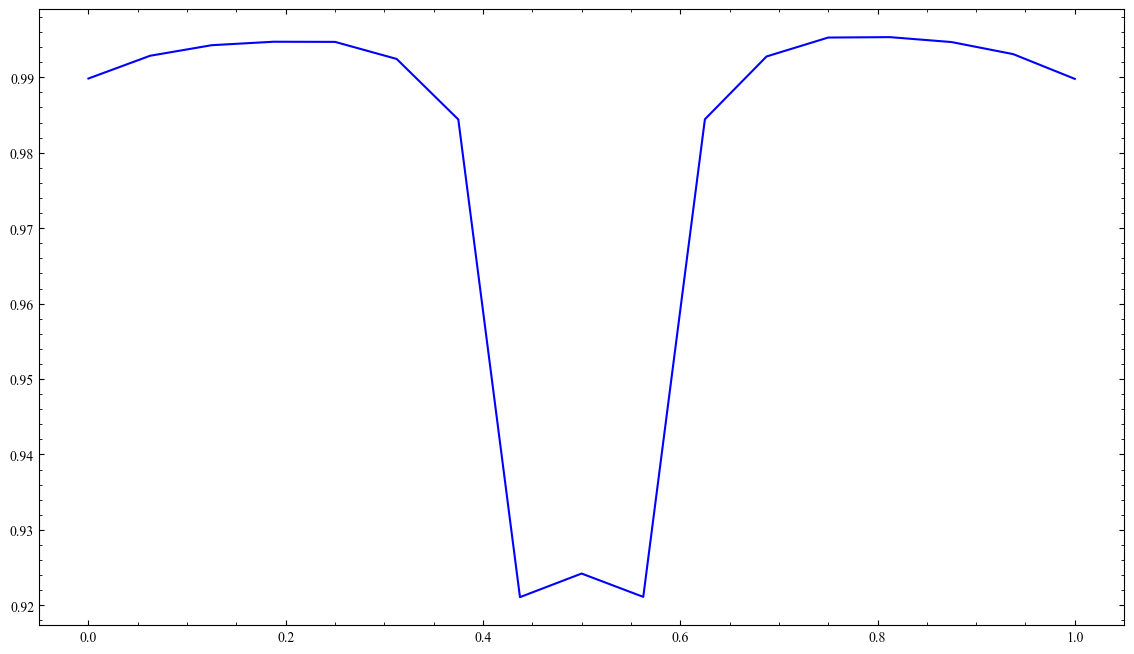

In [14]:
fig = plt.figure()
ax = fig.add_subplot()

df_subset = df_list[0][df_list[0]['q'] == 1e-04]

ax.plot(np.linspace(0, 1, 17), df_subset['1.1e-04'].to_list(), label='$1 \\times 10^{-4}$', color='blue')

plt.show()